## Exploratory Data Analysis (EDA)

In this stage of the project, exploratory data analysis (EDA) was performed to understand the differences between high popularity and low popularity songs.

The analysis was conducted using selected numerical audio features:
- energy
- danceability
- tempo
- valence
- loudness

### Steps Performed

1. **Basic Information**
   - Dataset sizes were examined
   - Selected features were listed

2. **Summary Statistics**
   - Descriptive statistics (mean, standard deviation, min, max) were computed for both groups

3. **Missing Value Analysis**
   - Checked for missing values in both datasets
   - No significant missing data was observed

4. **Mean Comparison**
   - The average values of each feature were compared between high and low popularity songs
   - This provides an initial indication of potential differences

5. **Distribution Analysis**
   - Separate histograms were plotted for each feature
   - This allows clear visualization without overlap between groups

6. **Feature Comparison**
   - Mean values were visualized using bar charts to highlight differences between groups

7. **Correlation Analysis**
   - Correlation matrices were generated for both high and low popularity datasets
   - This helps understand relationships between features within each group

### Purpose

The goal of this analysis is to identify patterns and differences between popular and non-popular songs before applying statistical hypothesis testing.

The findings from this section will guide the next step of the project, where statistical tests will be used to determine whether the observed differences are significant.

Files in current directory:
['.config', 'low_popularity_spotify_data.csv', 'high_popularity_spotify_data.csv', 'sample_data']
=== DATASET SHAPES ===
High popularity songs: (1686, 29)
Low popularity songs: (3145, 29)

=== SELECTED FEATURES ===
- energy
- danceability
- tempo
- loudness
- valence

=== SUMMARY STATISTICS: HIGH POPULARITY ===
            energy  danceability        tempo     loudness      valence
count  1686.000000   1686.000000  1686.000000  1686.000000  1686.000000
mean      0.667216      0.650362   121.070938    -6.704131     0.525737
std       0.184908      0.157721    27.066029     3.377068     0.236113
min       0.001610      0.136000    49.305000   -43.643000     0.034800
25%       0.551000      0.543250   100.058750    -7.950250     0.339000
50%       0.689000      0.664500   120.001000    -5.974500     0.528000
75%       0.807000      0.769000   136.833500    -4.687250     0.720000
max       0.990000      0.979000   209.688000     1.295000     0.978000

=== SUMMAR

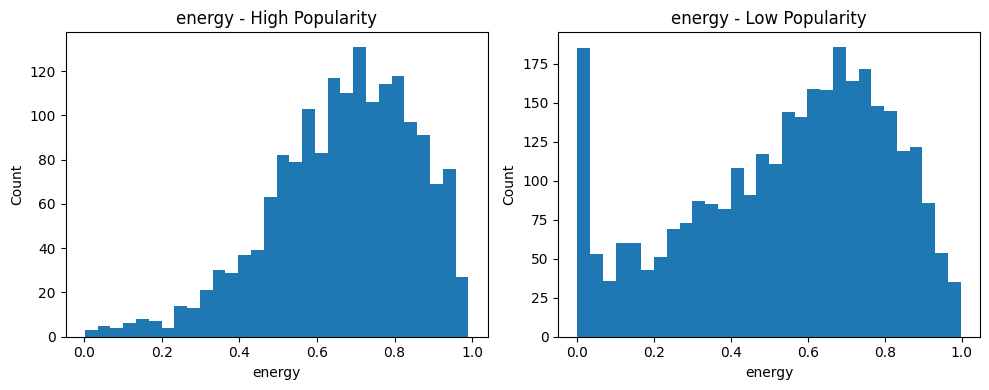

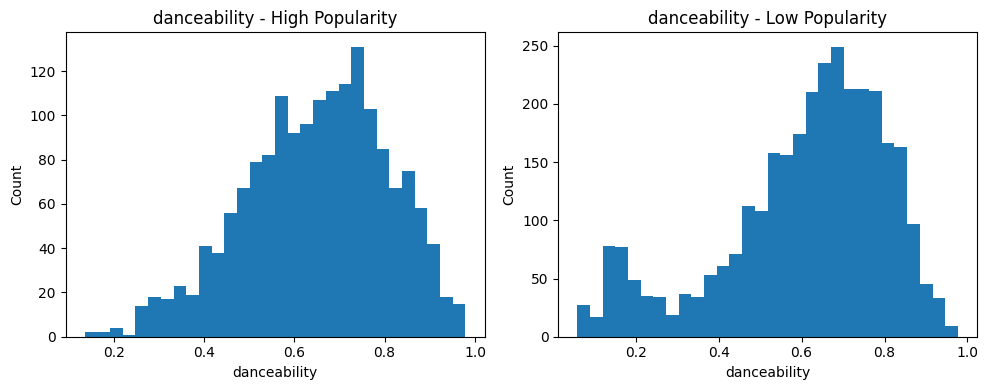

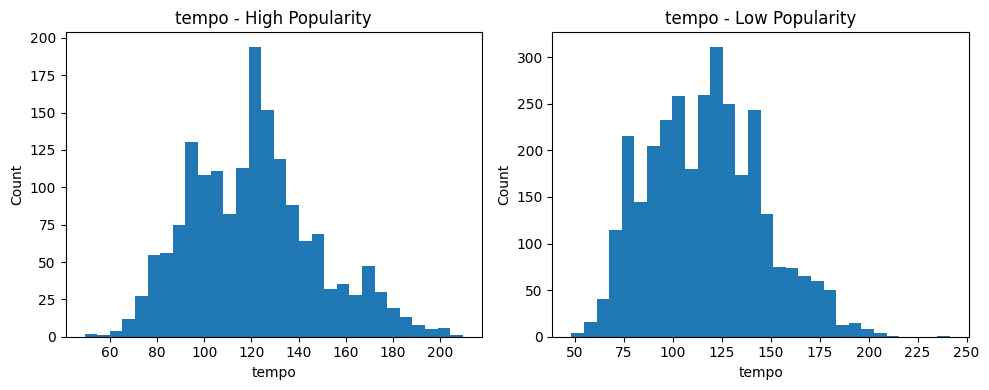

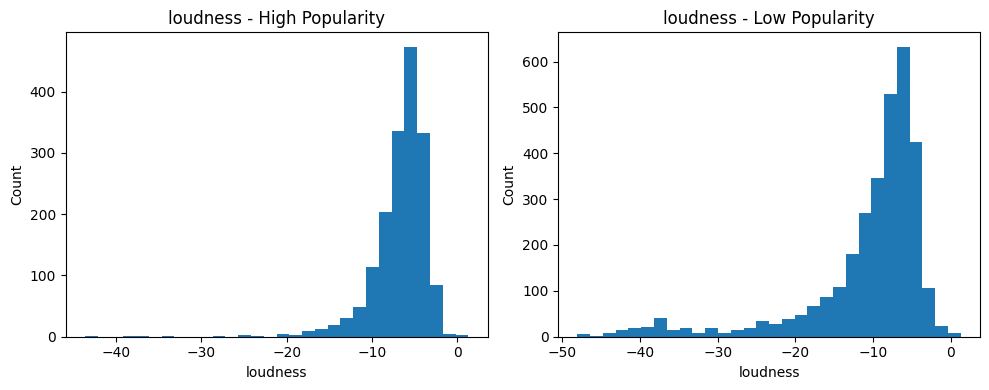

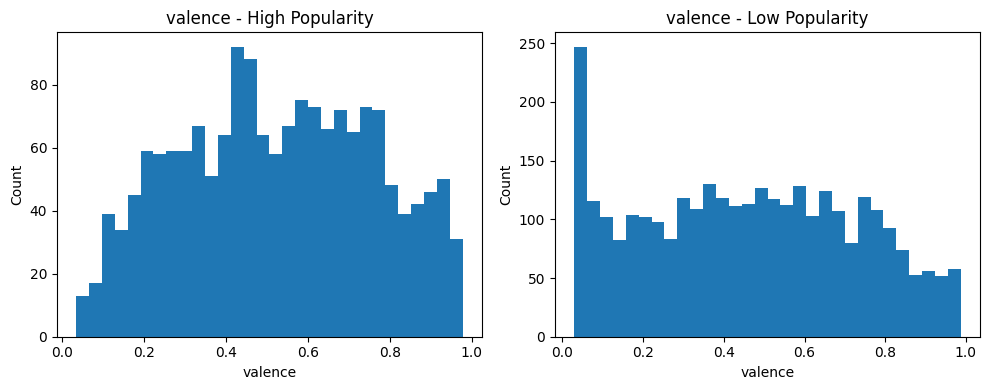

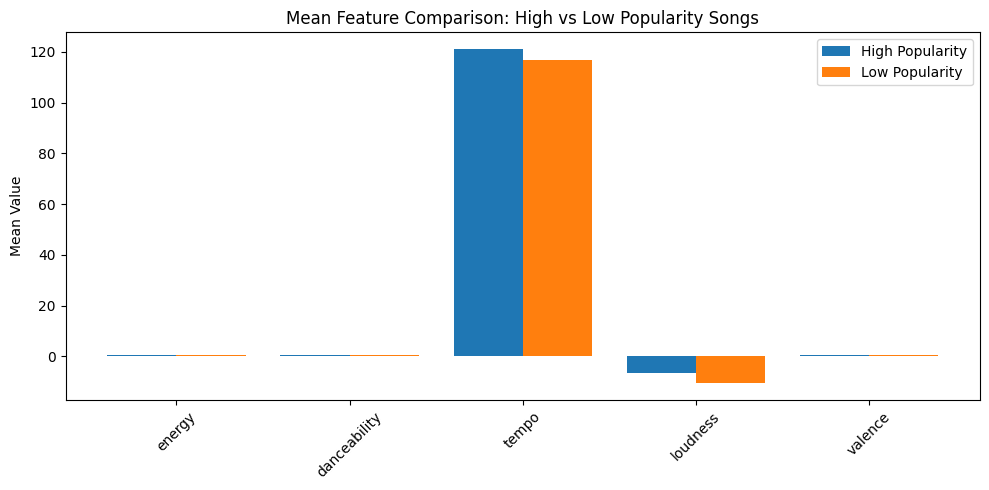

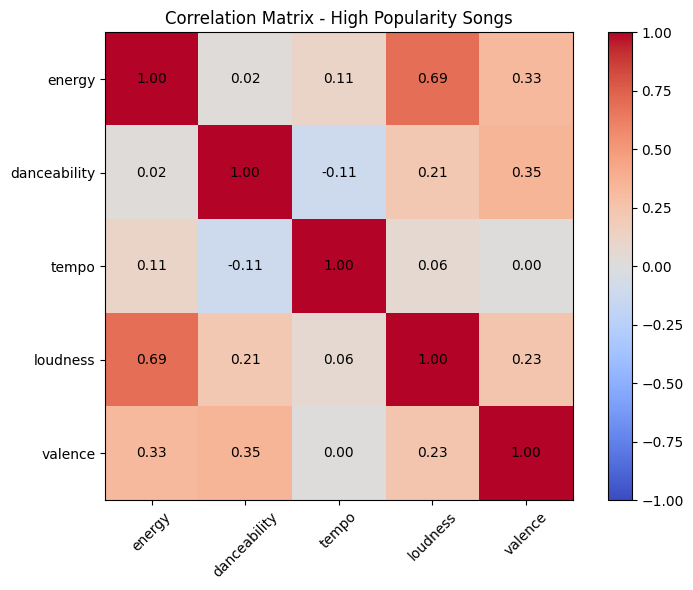

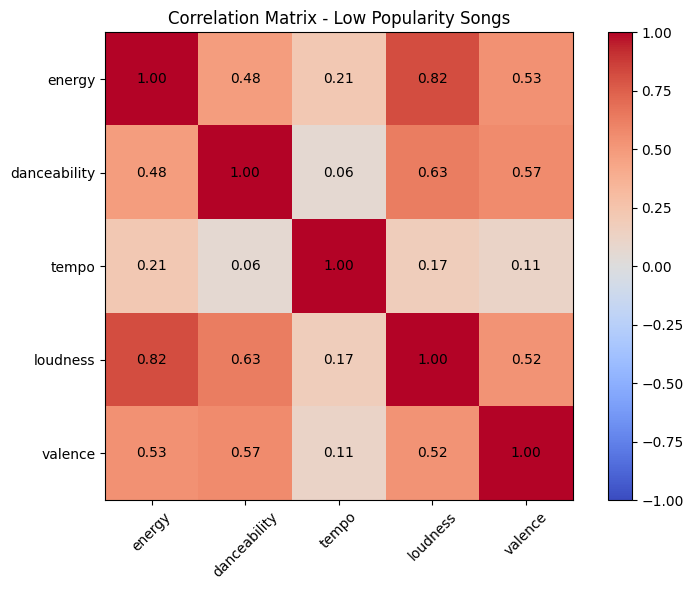

In [2]:
"""
02 - Exploratory Data Analysis (EDA)

This script performs exploratory data analysis on high and low popularity Spotify songs.

Main steps:
- Load datasets
- Check basic structure and missing values
- Compute summary statistics
- Compare mean values between groups
- Visualize distributions using histograms
- Compare features using bar charts
- Analyze correlations between features

The goal is to identify differences between the two groups before hypothesis testing.
"""

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

print("Files in current directory:")
print(os.listdir())

# file loading
high = pd.read_csv("high_popularity_spotify_data.csv")
low = pd.read_csv("low_popularity_spotify_data.csv")

# if your files have (1) in the name, use:
# high = pd.read_csv("high_popularity_spotify_data(1).csv")
# low = pd.read_csv("low_popularity_spotify_data(1).csv")

features = ['energy', 'danceability', 'tempo', 'loudness']

# add valence only if it exists
if 'valence' in high.columns and 'valence' in low.columns:
    features.append('valence')

# 1. BASIC INFORMATION
print("=== DATASET SHAPES ===")
print("High popularity songs:", high.shape)
print("Low popularity songs:", low.shape)

print("\n=== SELECTED FEATURES ===")
for feature in features:
    print("-", feature)

# 2. SUMMARY STATISTICS
print("\n=== SUMMARY STATISTICS: HIGH POPULARITY ===")
print(high[features].describe())

print("\n=== SUMMARY STATISTICS: LOW POPULARITY ===")
print(low[features].describe())

# 3. MISSING VALUE CHECK
print("\n=== MISSING VALUES: HIGH POPULARITY ===")
print(high[features].isnull().sum())

print("\n=== MISSING VALUES: LOW POPULARITY ===")
print(low[features].isnull().sum())

# 4. MEAN COMPARISON
print("\n=== MEAN COMPARISON ===")
for f in features:
    high_mean = high[f].mean()
    low_mean = low[f].mean()
    print(f"{f}")
    print("High mean:", high_mean)
    print("Low mean :", low_mean)
    print("-" * 30)

# 5. SEPARATE HISTOGRAMS
for f in features:
    plt.figure(figsize=(10, 4))

    plt.subplot(1, 2, 1)
    plt.hist(high[f].dropna(), bins=30)
    plt.title(f"{f} - High Popularity")
    plt.xlabel(f)
    plt.ylabel("Count")

    plt.subplot(1, 2, 2)
    plt.hist(low[f].dropna(), bins=30)
    plt.title(f"{f} - Low Popularity")
    plt.xlabel(f)
    plt.ylabel("Count")

    plt.tight_layout()
    plt.show()

# 6. MEAN BAR CHART
high_means = [high[f].mean() for f in features]
low_means = [low[f].mean() for f in features]

x = np.arange(len(features))

plt.figure(figsize=(10, 5))
plt.bar(x - 0.2, high_means, width=0.4, label='High Popularity')
plt.bar(x + 0.2, low_means, width=0.4, label='Low Popularity')

plt.xticks(x, features, rotation=45)
plt.ylabel("Mean Value")
plt.title("Mean Feature Comparison: High vs Low Popularity Songs")
plt.legend()
plt.tight_layout()
plt.show()

# 7. CORRELATION MATRIX - HIGH
corr_high = high[features].corr()

plt.figure(figsize=(8, 6))
plt.imshow(corr_high, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar()
plt.xticks(range(len(features)), features, rotation=45)
plt.yticks(range(len(features)), features)
plt.title("Correlation Matrix - High Popularity Songs")

for i in range(len(features)):
    for j in range(len(features)):
        plt.text(j, i, f"{corr_high.iloc[i, j]:.2f}",
                 ha='center', va='center', color='black')

plt.tight_layout()
plt.show()

# 8. CORRELATION MATRIX - LOW
corr_low = low[features].corr()

plt.figure(figsize=(8, 6))
plt.imshow(corr_low, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar()
plt.xticks(range(len(features)), features, rotation=45)
plt.yticks(range(len(features)), features)
plt.title("Correlation Matrix - Low Popularity Songs")

for i in range(len(features)):
    for j in range(len(features)):
        plt.text(j, i, f"{corr_low.iloc[i, j]:.2f}",
                 ha='center', va='center', color='black')

plt.tight_layout()
plt.show()

## Key Insight

Initial observations suggest that some audio features differ between high and low popularity songs. These differences will be further validated using statistical hypothesis tests in the next stage.